<a href="https://colab.research.google.com/github/Deeparam06-devcodes/Deeparepo/blob/main/Final_Project_League_of_Legends_Match_Predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset

# Load dataset
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/rk7VDaPjMp1h5VXS-cUyMg/league-of-legends-data-large.csv"
data = pd.read_csv(url)

# Features and target
X = data.drop('win', axis=1)
y = data['win']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Standardize
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert to tensors
X_train = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test = torch.tensor(X_test_scaled, dtype=torch.float32)

y_train = torch.tensor(
    y_train.values,
    dtype=torch.float32
).view(-1, 1)

y_test = torch.tensor(
    y_test.values,
    dtype=torch.float32
).view(-1, 1)

# DataLoaders
train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

# FULL BATCH = much faster
train_loader = DataLoader(
    train_dataset,
    batch_size=len(train_dataset),
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=len(test_dataset),
    shuffle=False
)

print("Dataset shape:", data.shape)
print("Training samples:", len(train_dataset))
print("Testing samples:", len(test_dataset))
print("Number of features:", X_train.shape[1])

Dataset shape: (1000, 9)
Training samples: 800
Testing samples: 200
Number of features: 8


In [2]:
import torch.nn as nn
import torch.optim as optim

class LogisticRegressionModel(nn.Module):

    def __init__(self, input_size, output_size):
        super(LogisticRegressionModel, self).__init__()

        self.linear = nn.Linear(
            input_size,
            output_size
        )

    def forward(self, x):
        return torch.sigmoid(self.linear(x))


# Create model
model = LogisticRegressionModel(
    input_size=X_train.shape[1],
    output_size=1
)

# Loss
criterion = nn.BCELoss()

# Optimizer
optimizer = optim.SGD(
    model.parameters(),
    lr=0.001
)

print(model)

LogisticRegressionModel(
  (linear): Linear(in_features=8, out_features=1, bias=True)
)


In [3]:
epochs = 1000

train_losses = []
test_losses = []

for epoch in range(epochs):

    # Training
    model.train()

    optimizer.zero_grad()

    outputs = model(X_train)

    loss = criterion(outputs, y_train)

    loss.backward()

    optimizer.step()

    train_losses.append(loss.item())

    # Evaluation
    model.eval()

    with torch.no_grad():

        train_outputs = model(X_train)
        test_outputs = model(X_test)

        train_predictions = torch.round(train_outputs)
        test_predictions = torch.round(test_outputs)

        train_accuracy = (
            train_predictions == y_train
        ).float().mean().item()

        test_accuracy = (
            test_predictions == y_test
        ).float().mean().item()

        test_loss = criterion(
            test_outputs,
            y_test
        ).item()

        test_losses.append(test_loss)

    if (epoch + 1) % 100 == 0:
        print(
            f"Epoch [{epoch+1}/{epochs}], "
            f"Train Loss: {loss.item():.4f}, "
            f"Train Accuracy: {train_accuracy:.4f}, "
            f"Test Accuracy: {test_accuracy:.4f}"
        )

print("\nFinal Training Accuracy:", round(train_accuracy, 4))
print("Final Test Accuracy:", round(test_accuracy, 4))

Epoch [100/1000], Train Loss: 0.7172, Train Accuracy: 0.5063, Test Accuracy: 0.5000
Epoch [200/1000], Train Loss: 0.7159, Train Accuracy: 0.5063, Test Accuracy: 0.5050
Epoch [300/1000], Train Loss: 0.7147, Train Accuracy: 0.5100, Test Accuracy: 0.5000
Epoch [400/1000], Train Loss: 0.7136, Train Accuracy: 0.5088, Test Accuracy: 0.5000
Epoch [500/1000], Train Loss: 0.7125, Train Accuracy: 0.5100, Test Accuracy: 0.5050
Epoch [600/1000], Train Loss: 0.7114, Train Accuracy: 0.5113, Test Accuracy: 0.5100
Epoch [700/1000], Train Loss: 0.7104, Train Accuracy: 0.5113, Test Accuracy: 0.5100
Epoch [800/1000], Train Loss: 0.7095, Train Accuracy: 0.5088, Test Accuracy: 0.5100
Epoch [900/1000], Train Loss: 0.7086, Train Accuracy: 0.5088, Test Accuracy: 0.5050
Epoch [1000/1000], Train Loss: 0.7077, Train Accuracy: 0.5088, Test Accuracy: 0.5100

Final Training Accuracy: 0.5088
Final Test Accuracy: 0.51


In [4]:
# L2 regularization
optimizer = optim.SGD(
    model.parameters(),
    lr=0.01,
    weight_decay=0.01
)

epochs = 1000

for epoch in range(epochs):

    model.train()

    optimizer.zero_grad()

    outputs = model(X_train)

    loss = criterion(outputs, y_train)

    loss.backward()

    optimizer.step()

    if (epoch + 1) % 100 == 0:
        model.eval()

        with torch.no_grad():
            train_pred = torch.round(model(X_train))
            test_pred = torch.round(model(X_test))

            train_acc = (
                train_pred == y_train
            ).float().mean().item()

            test_acc = (
                test_pred == y_test
            ).float().mean().item()

        print(
            f"Epoch [{epoch+1}/{epochs}], "
            f"Train Accuracy: {train_acc:.4f}, "
            f"Test Accuracy: {test_acc:.4f}"
        )

print("\nL2 Training Accuracy:", round(train_acc, 4))
print("L2 Test Accuracy:", round(test_acc, 4))

Epoch [100/1000], Train Accuracy: 0.5100, Test Accuracy: 0.5350
Epoch [200/1000], Train Accuracy: 0.5163, Test Accuracy: 0.5500
Epoch [300/1000], Train Accuracy: 0.5225, Test Accuracy: 0.5400
Epoch [400/1000], Train Accuracy: 0.5275, Test Accuracy: 0.5600
Epoch [500/1000], Train Accuracy: 0.5325, Test Accuracy: 0.5800
Epoch [600/1000], Train Accuracy: 0.5375, Test Accuracy: 0.5700
Epoch [700/1000], Train Accuracy: 0.5250, Test Accuracy: 0.5750
Epoch [800/1000], Train Accuracy: 0.5100, Test Accuracy: 0.5450
Epoch [900/1000], Train Accuracy: 0.5100, Test Accuracy: 0.5550
Epoch [1000/1000], Train Accuracy: 0.5200, Test Accuracy: 0.5450

L2 Training Accuracy: 0.52
L2 Test Accuracy: 0.545


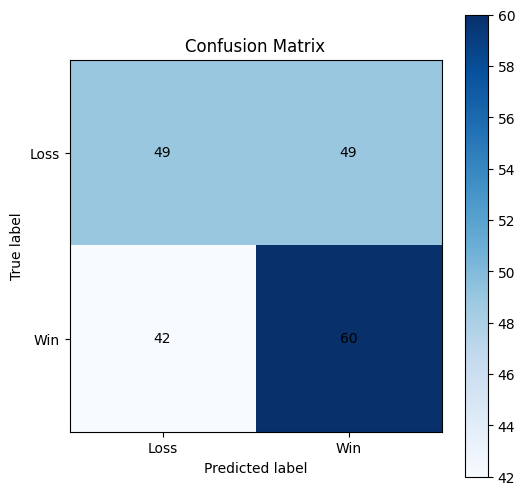

Classification Report:
              precision    recall  f1-score   support

        Loss       0.54      0.50      0.52        98
         Win       0.55      0.59      0.57       102

    accuracy                           0.55       200
   macro avg       0.54      0.54      0.54       200
weighted avg       0.54      0.55      0.54       200



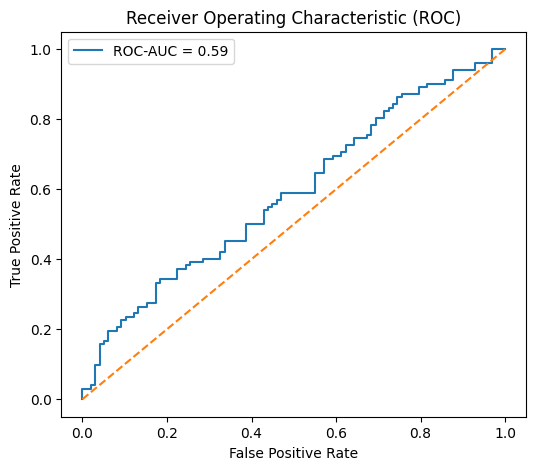

ROC-AUC: 0.5874


In [5]:
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

model.eval()

with torch.no_grad():
    y_pred_test = model(X_test).detach()

# Convert probabilities to labels
y_pred_test_labels = (
    y_pred_test > 0.5
).float()

# Confusion matrix
cm = confusion_matrix(
    y_test.numpy(),
    y_pred_test_labels.numpy()
)

plt.figure(figsize=(6, 6))
plt.imshow(cm, cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.colorbar()

plt.xticks(
    [0, 1],
    ["Loss", "Win"]
)

plt.yticks(
    [0, 1],
    ["Loss", "Win"]
)

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.show()


# Classification report
print("Classification Report:")
print(
    classification_report(
        y_test.numpy(),
        y_pred_test_labels.numpy(),
        target_names=["Loss", "Win"]
    )
)


# ROC curve
fpr, tpr, thresholds = roc_curve(
    y_test.numpy(),
    y_pred_test.numpy()
)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))

plt.plot(
    fpr,
    tpr,
    label=f"ROC-AUC = {roc_auc:.2f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC)")
plt.legend()

plt.show()

print("ROC-AUC:", round(roc_auc, 4))

In [6]:
# Save model
torch.save(
    model.state_dict(),
    "logistic_regression_model.pth"
)

print("Model saved successfully!")


# Create new model
loaded_model = LogisticRegressionModel(
    input_size=X_train.shape[1],
    output_size=1
)

# Load weights
loaded_model.load_state_dict(
    torch.load(
        "logistic_regression_model.pth",
        weights_only=True
    )
)

print("Model loaded successfully!")


# Evaluate loaded model
loaded_model.eval()

with torch.no_grad():

    outputs = loaded_model(X_test)

    predictions = torch.round(outputs)

    accuracy = (
        predictions == y_test
    ).float().mean().item()

print(
    f"Test Accuracy of Loaded Model: {accuracy:.4f}"
)

Model saved successfully!
Model loaded successfully!
Test Accuracy of Loaded Model: 0.5450


In [7]:
learning_rates = [0.01, 0.05, 0.1]

test_accuracies = {}

for lr in learning_rates:

    print(f"\nTraining with learning rate: {lr}")

    # New model for each learning rate
    tuned_model = LogisticRegressionModel(
        input_size=X_train.shape[1],
        output_size=1
    )

    tuned_optimizer = optim.SGD(
        tuned_model.parameters(),
        lr=lr
    )

    epochs = 50

    for epoch in range(epochs):

        tuned_model.train()

        tuned_optimizer.zero_grad()

        outputs = tuned_model(X_train)

        loss = criterion(
            outputs,
            y_train
        )

        loss.backward()

        tuned_optimizer.step()

    # Test
    tuned_model.eval()

    with torch.no_grad():

        predictions = torch.round(
            tuned_model(X_test)
        )

        accuracy = (
            predictions == y_test
        ).float().mean().item()

    test_accuracies[lr] = accuracy

    print(
        f"Test Accuracy for learning rate "
        f"{lr}: {accuracy:.4f}"
    )


# Best learning rate
best_lr = max(
    test_accuracies,
    key=test_accuracies.get
)

print("\nTest Accuracies:")
for lr, acc in test_accuracies.items():
    print(
        f"Learning Rate: {lr}, "
        f"Test Accuracy: {acc:.4f}"
    )

print(
    f"\nBest Learning Rate: {best_lr}, "
    f"Test Accuracy: {test_accuracies[best_lr]:.4f}"
)


Training with learning rate: 0.01
Test Accuracy for learning rate 0.01: 0.4600

Training with learning rate: 0.05
Test Accuracy for learning rate 0.05: 0.5250

Training with learning rate: 0.1
Test Accuracy for learning rate 0.1: 0.5300

Test Accuracies:
Learning Rate: 0.01, Test Accuracy: 0.4600
Learning Rate: 0.05, Test Accuracy: 0.5250
Learning Rate: 0.1, Test Accuracy: 0.5300

Best Learning Rate: 0.1, Test Accuracy: 0.5300


Feature Importance:
        Feature  Importance
5  wards_placed    0.081484
7  damage_dealt   -0.077443
3   gold_earned    0.059346
0         kills    0.043248
2       assists   -0.006610
4            cs    0.006283
1        deaths   -0.005179
6  wards_killed    0.003582


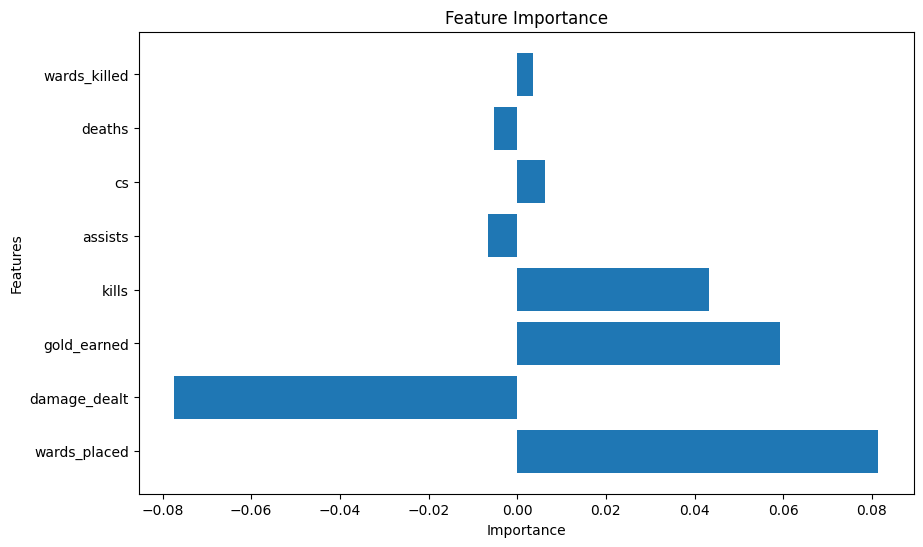


Top 3 Most Important Features:
        Feature  Importance
5  wards_placed    0.081484
7  damage_dealt   -0.077443
3   gold_earned    0.059346


In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# Get model weights
weights = (
    model.linear.weight
    .data
    .numpy()
    .flatten()
)

features = data.drop(
    'win',
    axis=1
).columns

# Create feature importance table
feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": weights
})

# Absolute importance for ranking
feature_importance["Absolute Importance"] = (
    feature_importance["Importance"].abs()
)

feature_importance = feature_importance.sort_values(
    by="Absolute Importance",
    ascending=False
)

print("Feature Importance:")
print(
    feature_importance[
        ["Feature", "Importance"]
    ]
)


# Plot
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Feature Importance")

plt.show()


# Top 3
print("\nTop 3 Most Important Features:")
print(
    feature_importance[
        ["Feature", "Importance"]
    ].head(3)
)